In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('capacitacion.csv')
df

,programa,calificacion
0,1,85
1,1,72
2,1,83
3,1,80
4,2,80
5,2,84
6,2,81
7,2,78
8,2,82
9,3,82


- H0 -> LOA 3 PROG SON IGUALMENTE EFICIENTES
- H1 -> ALGUN PROGRAMA ES DISTINTO A LOS OTROS

Text(0.6944444444444446, 0.5, ' Calificacion')

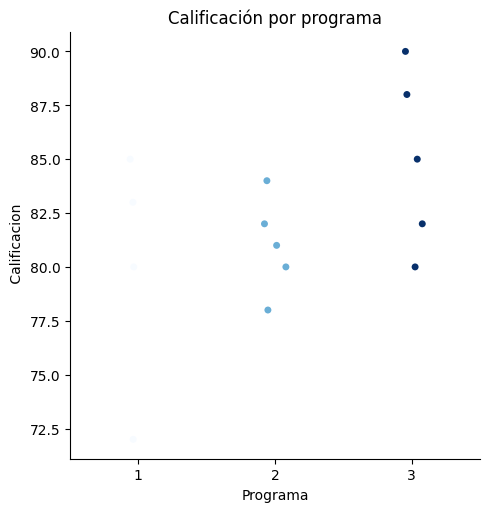

In [8]:
sns.catplot(x='programa',y='calificacion',hue='programa',data=df,palette='Blues',legend=False)
plt.title('Calificación por programa')
plt.xlabel('Programa')
plt.ylabel(' Calificacion')

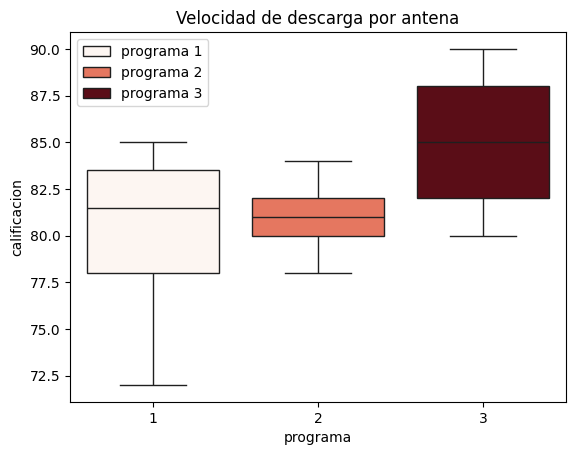

In [14]:
sns.boxplot(x='programa',y='calificacion',hue='programa',data=df,palette='Reds',orient = 'v')
plt.title('Velocidad de descarga por antena')
plt.xlabel('programa')
plt.ylabel('calificacion')
plt.legend(title='',labels=['programa 1','programa 2','programa 3'])

In [15]:
import scipy.stats as stats
f_statistic, p_value = stats.f_oneway(df.calificacion[df.programa==1],df.calificacion[df.programa==2],df.calificacion[df.programa==3])
print("Estadístico F:", f_statistic)
print("Valor p:", p_value)
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No rechazamos la hipótesis nula")

Estadístico F: 1.9431643625192017
Valor p: 0.18937730891510282
No rechazamos la hipótesis nula


In [17]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('calificacion ~ C(programa)', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)

aov_table

,sum_sq,df,F,PR(>F)
C(programa),65.714286,2.0,1.943164,0.189377
Residual,186.000000,11.0,NaN,NaN


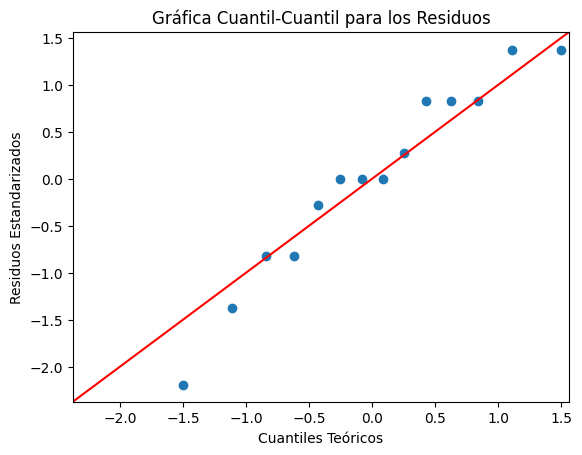

In [18]:
import statsmodels.stats.multicomp as mc


res = model.resid
sm.qqplot(res,fit=True ,line='45')
plt.title('Gráfica Cuantil-Cuantil para los Residuos')
plt.xlabel("Cuantiles Teóricos")
plt.ylabel("Residuos Estandarizados")
plt.show()

Text(0.5, 0.98, 'Verificación de Supuestos del Modelo ANOVA')

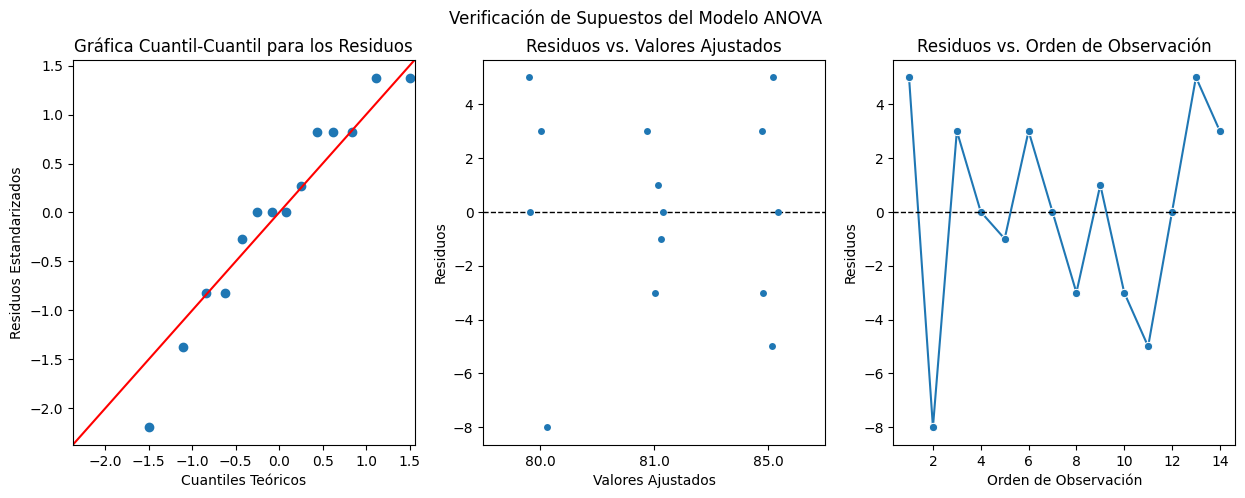

In [19]:
# Como las 3 son iguales, según la H0, nos saltamos la parte de tukey

# Verificación de Supuestos

fig, axs = plt.subplots(ncols=3,figsize=(15,5))

res = model.resid
sm.qqplot(res,fit=True ,line='45',ax=axs[0])
axs[0].set_title('Gráfica Cuantil-Cuantil para los Residuos')
axs[0].set_xlabel("Cuantiles Teóricos")
axs[0].set_ylabel("Residuos Estandarizados")



adj = model.fittedvalues.round(2)
sns.stripplot(x=adj,y=res,ax=axs[1])
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[1].set_ylabel('Residuos')
axs[1].set_xlabel('Valores Ajustados')
axs[1].set_title('Residuos vs. Valores Ajustados')


sns.lineplot(x=res.index+1,y=res,marker='o',ax=axs[2])
axs[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[2].set_title('Residuos vs. Orden de Observación')
axs[2].set_xlabel('Orden de Observación')
axs[2].set_ylabel('Residuos')

fig.suptitle('Verificación de Supuestos del Modelo ANOVA')
